# Experiments with hierarchical structure of text content
Prototyping an approach that combines both rule‐based and machine learning techniques to cluster document elements (pages, tables, paragraphs, sections, etc.) into semantic chunks based on key concepts and relationships:

---

### 1. Use Document Structure as a Starting Point

- **Sections as Natural Boundaries**:  
  Since the OCR output already includes a "sections" key with an ordered list of element pointers (e.g., “/paragraphs/0”, “/tables/2”), treat each section as a high-level unit.  
  - Extract all the content pointers from each section and gather the corresponding paragraphs, tables, figures, etc.

- **Key-Value Pairs for Data Relationships**:  
  Leverage the keyValuePairs to determine which pieces of text are functionally related (for example, a field label with its value). These can be merged with nearby text blocks in the same section.

---

### 2. Extract and Prepare Content for Semantic Analysis

- **Content Extraction**:  
  For each section, resolve the element pointers (e.g., "/paragraphs/1") to get the actual text, geometric positions, and any style metadata.

- **Preprocessing**:  
  - Concatenate related text segments from the same section if they appear to form a continuous thought.  
  - Optionally, include geometric cues (e.g., position or style features) if the document’s layout is significant.

- **Generate Representations**:  
  Compute text embeddings for each element using a model like Sentence-BERT or a multi-modal transformer (e.g., LayoutLMv3) that can combine textual and layout features. These embeddings will capture the semantic content.

---

### 3. Cluster Content Within and Across Sections

- **Within-Section Clustering**:  
  Within each section, you might further cluster content if the section itself contains multiple key concepts. For example, a "Results" section might have sub-clusters for numerical findings vs. descriptive paragraphs.
  - Use clustering algorithms (e.g., k-means or hierarchical clustering) on the embeddings of the section’s elements.
  - Adjust cluster granularity based on the number of elements and the expected diversity of key concepts.

- **Across-Section Relationships**:  
  If you need to find similarities between sections (for example, grouping together sections that are part of the introduction), you can compute embeddings for an entire section (by aggregating its element embeddings) and then cluster sections themselves.

- **Relationship-Based Refinement**:  
  Use key-value pairs and document metadata (like logical roles: headers, footers, etc.) as additional signals. For instance, if certain paragraphs are paired with key-value pairs (e.g., "Budget:" and "$10,000"), they likely belong in a single semantic group.

---

### 4. Merge and Label Semantic Chunks

- **Chunk Assembly**:  
  Once clusters are formed, merge the clustered items into semantic chunks. Each chunk should encapsulate:
  - A key concept (which might be determined by summarizing the text or by identifying a prominent heading).  
  - Supporting content (tables, figures, paragraphs, key-value pairs).

- **Annotation or Summarization**:  
  Optionally, run a summarization or classification step on each semantic chunk to assign it a label (e.g., “Introduction,” “Methodology,” “Results,” “Discussion”) or a custom key concept relevant to your domain.

---

### 5. Example Workflow Outline

1. **Load and Parse the OCR JSON**:  
   - Extract keys like `sections`, `paragraphs`, `tables`, etc.
   - For each section, follow the pointers in `sections/elements` to fetch the actual content.

2. **Preprocess Content**:  
   - Normalize text (e.g., remove extra whitespace).
   - Optionally, extract additional metadata (bounding boxes, styles).

3. **Compute Embeddings**:  
   - Use a text embedding model to encode the content of each element.

4. **Cluster the Elements**:  
   - Apply a clustering algorithm within each section (and optionally across sections) based on the embeddings.
   - Fine-tune the number of clusters or use a method that automatically determines clusters (e.g., DBSCAN).

5. **Assemble Semantic Chunks**:  
   - Group clusters into semantic chunks.
   - Optionally, apply a summarization model to label each chunk with a key concept.

6. **Post-Processing**:  
   - Merge adjacent or overlapping chunks using geometric cues.
   - Cross-reference key-value pairs to ensure related items are clustered together.

---

### 6. Considerations and Tools

- **Heuristic Rules**:  
  Simple rules (e.g., “if a table’s bounding box is within the vertical range of a heading’s section, attach it to that section”) can be very effective in documents with consistent layouts.

- **Machine Learning**:  
  Use pre-trained models for embeddings and clustering. Experiment with both sentence transformers and layout-aware models to see which best capture the semantic relationships.

- **Visualization and Manual Review**:  
  Visualize clusters (e.g., with t-SNE or UMAP) and conduct manual reviews to validate the semantic coherence of chunks.

---

### Final Thoughts

By combining the logical structure provided by headings and sections with geometric and key-value relationship cues, you can form semantic chunks that encapsulate key concepts along with their supporting data. This hybrid approach—using rule-based grouping for known structural elements and machine learning to capture semantic similarity—offers both interpretability and adaptability to different document types.

## OCR JSON Structure Documentation

This document describes the structure of the OCR JSON output (from Azure or a similar OCR service). The JSON contains a mix of extracted content (words, lines, paragraphs) along with their geometric and logical information, key-value pairs, tables, styles, language detection, sections, and figures.

---

### Top-Level Keys

- **apiVersion**  
  - *Type:* String  
  - *Description:* The API version used for the OCR output (e.g., `"2024-07-31-preview"`).

- **modelId**  
  - *Type:* String  
  - *Description:* Identifier of the OCR model used (e.g., `"prebuilt-layout"`).

- **stringIndexType**  
  - *Type:* String  
  - *Description:* Indicates how string indices are measured (e.g., `"utf16CodeUnit"`).

- **content**  
  - *Type:* String  
  - *Description:* The full raw text content extracted from the document. This is typically the concatenation of all recognized text.

- **contentFormat**  
  - *Type:* String  
  - *Description:* The format of the extracted content (e.g., `"text"`).

---

### Document Components

#### Pages

- **pages**  
  - *Type:* Array of Page Objects  
  - *Description:* Contains information for each page of the document.

Each **page** object includes:
  - **pageNumber**  
    - *Type:* Integer  
    - *Description:* The page number.
  - **angle**  
    - *Type:* Number (or `null`)  
    - *Description:* The rotation angle of the page.
  - **width**, **height**  
    - *Type:* Number  
    - *Description:* Dimensions of the page in the specified unit.
  - **unit**  
    - *Type:* String  
    - *Description:* The unit of measurement (e.g., `"pixel"`).
  - **words**  
    - *Type:* Array of Word Objects  
    - *Description:* Each word object contains:
      - **content:** The word text.
      - **polygon:** A flat array of numbers representing the polygon coordinates (e.g., `[x1, y1, x2, y2, ..., xN, yN]`).
      - **confidence:** Confidence score for the word.
      - **span:** An object with `offset` and `length` that indicate the position of this word in the overall text.
  - **lines**  
    - *Type:* Array of Line Objects  
    - *Description:* Each line object has:
      - **content:** The full text of the line.
      - **polygon:** The polygon coordinates (flat array) that enclose the line.
      - **spans:** List of span objects (each with `offset` and `length`).
  - **selectionMarks**  
    - *Type:* Array  
    - *Description:* Contains objects for selection marks (e.g., checkboxes), each with:
      - **state:** (e.g., `"selected"` or `"unselected"`).
      - **polygon:** The coordinates.
      - **confidence:** Confidence score.
      - **span:** The text span information.

---

#### Tables

- **tables**  
  - *Type:* Array of Table Objects  
  - *Description:* Represents tables extracted from the document.

Each **table** object includes:
  - **rowCount** and **columnCount**  
    - *Type:* Integer  
    - *Description:* The number of rows and columns.
  - **cells**  
    - *Type:* Array of Cell Objects  
    - *Description:* Each cell object may contain:
      - **kind:** The type of cell (e.g., `"columnHeader"`, `"body"`).
      - **rowIndex**, **columnIndex:** Position within the table.
      - **content:** The cell text.
      - **boundingRegions:** List of regions (each with a pageNumber and a flat polygon array).
      - **spans:** Span objects for text offsets.
      - **elements:** Pointers (e.g., `"/paragraphs/6"`) to the corresponding paragraph(s).
  - **boundingRegions**  
    - *Type:* Array  
    - *Description:* The overall region(s) where the table is located.
  - **spans**  
    - *Type:* Array  
    - *Description:* Span objects corresponding to the table text.

---

#### Paragraphs

- **paragraphs**  
  - *Type:* Array of Paragraph Objects  
  - *Description:* Contains the main text blocks extracted from the document.

Each **paragraph** object includes:
  - **spans**  
    - *Type:* Array of Span Objects  
    - *Description:* Each span contains:
      - **offset:** The starting position in the overall text.
      - **length:** The length of the text in this span.
  - **boundingRegions**  
    - *Type:* Array of Bounding Region Objects  
    - *Description:* Each region has:
      - **pageNumber:** The page number.
      - **polygon:** A flat array of numbers representing the bounding box of the paragraph.
  - **role** (Optional)  
    - *Type:* String  
    - *Description:* Logical role of the paragraph (e.g., `"title"`, `"pageFooter"`).
  - **content**  
    - *Type:* String  
    - *Description:* The text content of the paragraph.

---

#### Key-Value Pairs

- **keyValuePairs**  
  - *Type:* Array of Key-Value Pair Objects  
  - *Description:* Represents pairs of keys and values (often found in forms).

Each key-value pair object includes:
  - **key**  
    - *Type:* Object  
    - *Description:* Contains:
      - **content:** The key text.
      - **boundingRegions:** List of regions for the key.
      - **spans:** Span objects for text offsets.
  - **value**  
    - *Type:* Object  
    - *Description:* Contains:
      - **content:** The value text.
      - **boundingRegions:** List of regions for the value.
      - **spans:** Span objects.
  - **confidence**  
    - *Type:* Number  
    - *Description:* Confidence score for the key-value extraction.

---

#### Styles

- **styles**  
  - *Type:* Array of Style Objects  
  - *Description:* Contains style-related information such as font properties and handwriting detection.
  
Each **style** object includes:
  - **confidence:** Confidence score for the style detection.
  - **spans:** List of span objects indicating where this style applies.
  - **isHandwritten:** Boolean indicating if the text is handwritten.

---

#### Languages

- **languages**  
  - *Type:* Array of Language Objects  
  - *Description:* Contains language detection results for different spans of text.
  
Each **language** object includes:
  - **spans:** List of spans (with `offset` and `length`) where the language is detected.
  - **locale:** The language locale (e.g., `"en"`, `"pl"`).
  - **confidence:** Confidence score for the language detection.

---

#### Sections

- **sections**  
  - *Type:* Array of Section Objects  
  - *Description:* Logical sections of the document. Each section groups related elements.

Each **section** object includes:
  - **spans:** Array of span objects indicating which portions of the overall text belong to this section.
  - **elements:** Array of pointers (strings like `"/paragraphs/0"` or `"/tables/2"`) referencing the elements that belong to the section.

---

#### Figures

- **figures**  
  - *Type:* Array of Figure Objects  
  - *Description:* Represents images or figures extracted from the document.

Each **figure** object includes:
  - **id:** Identifier for the figure.
  - **boundingRegions:** Array of regions (each with a pageNumber and flat polygon array).
  - **spans:** Array of span objects.
  - **elements:** Array of pointers to associated paragraphs (if applicable).

---

### Example JSON Skeleton

Below is an example JSON snippet that shows the structure with inline comments (in Markdown, comments are shown as plain text):

```json
{
  "apiVersion": "2024-07-31-preview",
  "modelId": "prebuilt-layout",
  "stringIndexType": "utf16CodeUnit",
  "content": "Full raw text content...",
  "contentFormat": "text",
  "pages": [
    {
      "pageNumber": 1,
      "angle": 0.14,
      "width": 762,
      "height": 1000,
      "unit": "pixel",
      "words": [
        {
          "content": "MARKETING",
          "polygon": [238, 41, 302, 40, 302, 56, 238, 56],
          "confidence": 0.989,
          "span": {"offset": 0, "length": 9}
        }
        // ... more words ...
      ],
      "lines": [
        {
          "content": "MARKETING RESEARCH AUTHORIZATIU ..",
          "polygon": [238, 40, 466, 40, 466, 56, 238, 56],
          "spans": [{"offset": 0, "length": 34}]
        }
        // ... more lines ...
      ]
    }
    // ... more pages ...
  ],
  "tables": [
    {
      "rowCount": 3,
      "columnCount": 5,
      "cells": [
        {
          "kind": "columnHeader",
          "rowIndex": 0,
          "columnIndex": 0,
          "content": "",
          "boundingRegions": [
            {"pageNumber": 1, "polygon": [278, 109, 291, 109, 291, 138, 278, 138]}
          ],
          "spans": []
        }
        // ... more cells ...
      ],
      "boundingRegions": [
        {"pageNumber": 1, "polygon": [311, 121, 623, 121, 623, 167, 310, 167]}
      ],
      "spans": [{"offset": 170, "length": 44}]
    }
    // ... more tables ...
  ],
  "paragraphs": [
    {
      "spans": [{"offset": 0, "length": 66}],
      "boundingRegions": [
        {"pageNumber": 1, "polygon": [238, 40, 466, 40, 466, 70, 238, 71]}
      ],
      "role": "title",
      "content": "MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)"
    }
    // ... more paragraphs ...
  ],
  "keyValuePairs": [
    {
      "key": {
        "content": "Date:",
        "boundingRegions": [
          {"pageNumber": 1, "polygon": [80, 69, 114, 69, 114, 84, 80, 84]}
        ],
        "spans": [{"offset": 67, "length": 5}]
      },
      "value": {
        "content": "4/16/90",
        "boundingRegions": [
          {"pageNumber": 1, "polygon": [121, 69, 181, 69, 181, 83, 121, 83]}
        ],
        "spans": [{"offset": 73, "length": 7}]
      },
      "confidence": 0.999
    }
    // ... more keyValuePairs ...
  ],
  "styles": [
    {
      "confidence": 1,
      "spans": [{"offset": 1034, "length": 11}],
      "isHandwritten": true
    }
    // ... more styles ...
  ],
  "languages": [
    {
      "spans": [{"offset": 0, "length": 34}],
      "locale": "en",
      "confidence": 0.4
    }
    // ... more languages ...
  ],
  "sections": [
    {
      "spans": [
        {"offset": 0, "length": 214},
        {"offset": 1349, "length": 12},
        {"offset": 215, "length": 27},
        {"offset": 1362, "length": 12},
        {"offset": 243, "length": 1062}
      ],
      "elements": [
        "/paragraphs/0",
        "/paragraphs/1",
        "/paragraphs/2"
        // ... additional element pointers ...
      ]
    }
  ],
  "figures": [
    {
      "id": "1.1",
      "boundingRegions": [
        {"pageNumber": 1, "polygon": [229, 25, 474, 25, 474, 71, 229, 71]}
      ],
      "spans": [{"offset": 0, "length": 66}],
      "elements": ["/paragraphs/0"]
    }
  ]
}
```

---

### Coding starts here.

---

In [1]:
import json
import re

# 1. Load your OCR JSON
ocr_filename  = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged4b.json'

with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)


---

### Look at JSON top keys

---

In [2]:
def print_keys(data, indent=0):
    """
    Recursively print keys from a nested dictionary (and lists) with hierarchical indentation.
    """
    prefix = " " * indent
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{prefix}{key}")
            print_keys(value, indent + 2)
    elif isinstance(data, list):
        for item in data:
            print_keys(item, indent)

def print_top_keys(data):
    if isinstance(data, dict):
        for key in data.keys():
            print(key)
    else:
        print("Not a dictionary")

#print_keys(ocr_data, indent=2)
print_top_keys(ocr_data)

apiVersion
modelId
stringIndexType
content
pages
tables
paragraphs
keyValuePairs
styles
languages
contentFormat
sections
figures


---

## The code below clusters paragraphs to find new "sections"

---

Below is a minimal Python example that uses Sentence-BERT via the sentence-transformers library. This snippet loads the "all-MiniLM-L6-v2" model, embeds a list of texts, and prints the resulting embeddings.

This is an example using both cosine similarity and Euclidean distance with embeddings produced by Sentence-BERT:

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np

# Load the Sentence-BERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Sample list of texts from your document sections or paragraphs
texts = [
    "This is the introduction of the document, providing an overview of the study.",
    "The methodology section explains the data collection and analysis process.",
    "Results show significant improvement in performance after applying the algorithm.",
    "In the discussion, we compare our findings with related work in the field."
]

# Generate embeddings for each text
embeddings = model.encode(texts, show_progress_bar=True)

# Print the embeddings
for text, embedding in zip(texts, embeddings):
    print(f"Text: {text}")
    print(f"Embedding: {embedding[:10]}...")  # Print first 10 dimensions for brevity
    print()

# Compute cosine similarity matrix
cos_sim_matrix = cosine_similarity(embeddings)
print("Cosine Similarity Matrix:")
print(cos_sim_matrix)

# Compute Euclidean distance matrix
euclidean_matrix = euclidean_distances(embeddings)
print("\nEuclidean Distance Matrix:")
print(euclidean_matrix)

# Example: Distance between first and second text
print("\nCosine similarity between text 0 and text 1:", cos_sim_matrix[0][1])
print("Euclidean distance between text 0 and text 1:", euclidean_matrix[0][1])

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Text: This is the introduction of the document, providing an overview of the study.
Embedding: [-0.00559058  0.088334    0.00694797  0.07140665 -0.05149508  0.06170814
 -0.04764654  0.13979359 -0.05198829  0.0203247 ]...

Text: The methodology section explains the data collection and analysis process.
Embedding: [-0.0104163   0.05293079 -0.11374742 -0.00872538  0.00608292 -0.04338054
 -0.07721034  0.02532059 -0.04444307  0.02908137]...

Text: Results show significant improvement in performance after applying the algorithm.
Embedding: [ 0.02957356  0.07892517  0.00616034 -0.04892756 -0.04271282 -0.07028975
 -0.03516496  0.00915298 -0.0744353  -0.05780991]...

Text: In the discussion, we compare our findings with related work in the field.
Embedding: [-0.06938256  0.01839469 -0.03977845  0.00192981  0.04704428  0.00106177
 -0.00266044  0.06965948  0.03450458 -0.03785924]...

Cosine Similarity Matrix:
[[1.         0.44069102 0.0717814  0.441912  ]
 [0.44069102 1.         0.2357136  0.3431

Below is an example Python script that shows one way to cluster document elements semantically using a Sentence-BERT model and a clustering algorithm. In this example, we extract the text from the OCR’s paragraphs (which are one of the top-level keys), compute embeddings using Sentence-BERT, and then cluster those embeddings with KMeans. You can extend the same idea to combine text from tables, sections (by following the “elements” pointers), or even pages.

In [11]:
import json
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

def load_ocr_json(file_path):
    """Load the OCR JSON from a file."""
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_paragraph_texts(ocr_data):
    """
    Extract text and identifiers from the OCR paragraphs.
    You could similarly extract table text or combine them using the 
    'sections' key that points to pointers like "/paragraphs/0", etc.
    """
    paragraphs = ocr_data.get("paragraphs", [])
    texts = []
    ids = []
    for para in paragraphs:
        # check if valid
        if para.get("invalid", False):
            continue
        
        # get paragraph id
        idx = para.get("id", -1)
        
        # Get the 'content' field from each paragraph.
        text = para.get("content", "").strip()
        if text:  # Skip empty ones if desired
            texts.append(text)
            ids.append(idx)
    return ids, texts

def cluster_texts(texts, num_clusters=5):
    """
    Compute embeddings for each text using Sentence-BERT and cluster them using KMeans.
    Adjust num_clusters based on your data and domain.
    """
    # Load a pre-trained Sentence-BERT model (e.g., "all-MiniLM-L6-v2")
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(texts, show_progress_bar=True)

    # Use KMeans to cluster embeddings
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    return labels, embeddings


# Path to your OCR JSON file
#ocr_file = "ocr_output.json"

# Load the OCR data
#ocr_data = load_ocr_json(ocr_file)

# Extract paragraph texts (or combine text from other elements as needed)
ids, texts = extract_paragraph_texts(ocr_data)

# Cluster the texts (adjust the number of clusters as needed)
num_clusters = 5  # For example, you might expect five key semantic chunks
labels, embeddings = cluster_texts(texts, num_clusters=num_clusters)

# Print out each paragraph with its assigned cluster label
cluster_labels = {}
for pid, text, label in zip(ids, texts, labels):
    cluster_labels[pid] = label.item()
    print(f"Paragraph {pid} (Cluster {label}): {text}\n")

print("Cluster Label Dictionary:", cluster_labels)


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Paragraph 0 (Cluster 4): MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)

Paragraph 1 (Cluster 1): Date: 4/16/90

Paragraph 2 (Cluster 2): Description: Y-1 Ultra 100's vs. Winston Ultra 100's

Paragraph 3 (Cluster 2): Requested By: W. T. Carpenter

Paragraph 6 (Cluster 4): Research

Paragraph 7 (Cluster 2): Request Attached:

Paragraph 8 (Cluster 2): Yes :selected: No
:unselected:

Paragraph 9 (Cluster 0): Budgeted:

Paragraph 10 (Cluster 2): Yes :selected: No
:unselected:

Paragraph 11 (Cluster 3): Original

Paragraph 14 (Cluster 0): Competitive Proposals Obtained: Est. Cost Per Supplier Cost ($) Travel Total Cost Interview

Paragraph 15 (Cluster 2): Kapuler

Paragraph 16 (Cluster 0): $33.675 +10%Est.

Paragraph 17 (Cluster 3): $2000

Paragraph 18 (Cluster 2): :selected: $35,675

Paragraph 19 (Cluster 3): $84.2

Paragraph 20 (Cluster 4): Market Facts

Paragraph 21 (Cluster 0): $35.000 +10%Est.

Paragraph 22 (Cluster 3): $2000

Paragraph 23 (Cluster 0): $37,000

Para

Below is an example that shows how you might combine text‐embedding similarity (from Sentence-BERT) with spatial proximity (derived from bounding box centers) into a composite similarity matrix. In this example, we compute the cosine similarity between paragraph embeddings and a spatial similarity score (using a Gaussian kernel on the Euclidean distance between bounding box centers). We then weight these two scores (using a parameter α) and run spectral clustering with the combined affinity matrix.

---

### Explanation

1. **Loading & Extraction:**  
   We load the OCR JSON and extract paragraphs. For each paragraph, we get its text and compute the center of its bounding box (using the first available bounding region).

2. **Text Similarity:**  
   We compute embeddings for each paragraph using Sentence-BERT and then calculate a cosine similarity matrix.

3. **Spatial Similarity:**  
   For each pair of paragraph centers, we compute a Gaussian kernel–based similarity. The parameter σ controls how fast the similarity falls off with distance.

4. **Composite Similarity:**  
   We then compute a weighted sum of the text and spatial similarities. The parameter α lets you weight text more heavily (or spatial proximity more heavily if set lower).

5. **Clustering:**  
   We use spectral clustering with the composite affinity matrix to cluster paragraphs. You can adjust the number of clusters based on your document.

6. **Output:**  
   Finally, we print each paragraph with its cluster label. This should favor clustering paragraphs that are both semantically similar (by text) and physically close (by bounding box center).

This approach helps ensure that adjacent paragraphs (which are more likely to be part of the same semantic chunk) receive a higher composite similarity and thus are more likely to be clustered together.

In [15]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering

def load_ocr_json(file_path):
    """Load OCR JSON from file."""
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_paragraphs(ocr_data):
    """
    Extract paragraph texts and bounding boxes.
    Here, we assume each paragraph has a "content" string and a list of "boundingRegions".
    We take the first bounding region and compute its center.
    Returns lists of texts and centers (as [x_center, y_center]).
    """
    paragraphs = ocr_data.get("paragraphs", [])
    texts = []
    centers = []
    ids = []
    
    for para in paragraphs:
        # check if valid
        if para.get("invalid", False):
            #print("Invalid id", str(para.get("id", -1)))
            continue
        # else:
        #     print("Valid id", str(para.get("id", -1)))

        # check if it has a role
        if para.get("role", "") != "":
            print("Paragraph has role", str(para.get("role", "")))
            continue

        text = para.get("content", "").strip()
        if not text:
            continue

        # Use the first bounding region to compute the center.
        brs = para.get("boundingRegions", [])
        if not brs:
            continue
        # Each bounding region has a "polygon" of points: [x1, y1, x2, y2, ..., xN, yN]
        # We'll assume the polygon is rectangular and compute center from min/max.
        poly = brs[0].get("polygon", [])
        if not poly or len(poly) < 4:
            continue

        # save paragraph id
        ids.append(para.get("id", -1))

        # Convert polygon list into pairs:
        pts = np.array(poly).reshape(-1, 2)
        x_min, y_min = pts.min(axis=0)
        x_max, y_max = pts.max(axis=0)
        center = [(x_min + x_max) / 2, (y_min + y_max) / 2]

        texts.append(text)
        centers.append(center)
    return ids, texts, np.array(centers)

def compute_spatial_similarity(centers, sigma=50.0):
    """
    Compute spatial similarity matrix given the centers of paragraphs.
    We use a Gaussian kernel: sim(i, j) = exp(-||center_i - center_j||^2 / (2 * sigma^2))
    sigma should be set according to the scale of your coordinates.
    """
    num = centers.shape[0]
    sim = np.zeros((num, num))
    for i in range(num):
        for j in range(num):
            dist = np.linalg.norm(centers[i] - centers[j])
            sim[i, j] = np.exp(- (dist ** 2) / (2 * sigma ** 2))
    return sim

def compute_text_similarity(texts, model):
    """Compute cosine similarity between paragraph embeddings."""
    embeddings = model.encode(texts, show_progress_bar=True)
    return cosine_similarity(embeddings), embeddings

def composite_similarity(text_sim, spatial_sim, alpha=0.7):
    """
    Combine text and spatial similarities.
    alpha: weight for text similarity, (1-alpha) for spatial.
    """
    return alpha * text_sim + (1 - alpha) * spatial_sim

def cluster_paragraphs(affinity, n_clusters=5):
    """
    Cluster paragraphs using Spectral Clustering with a precomputed affinity matrix.
    """
    sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
    return sc.fit_predict(affinity)

# Load OCR data from file
ocr_filename  = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged4b.json'
ocr_data = load_ocr_json(ocr_filename)

# Extract paragraph texts and bounding box centers
ids, texts, centers = extract_paragraphs(ocr_data)
if not texts:
    print("No paragraphs found!")
else:

    # Load Sentence-BERT model
    model = SentenceTransformer("all-MiniLM-L6-v2")

    # Compute text similarity matrix
    text_sim, embeddings = compute_text_similarity(texts, model)

    # Compute spatial similarity matrix (sigma is a tuning parameter)
    spatial_sim = compute_spatial_similarity(centers, sigma=50.0)

    # Combine similarities: alpha controls weighting (0 <= alpha <= 1)
    alpha = 0.3  # Higher weight for text similarity
    affinity = composite_similarity(text_sim, spatial_sim, alpha=alpha)

    # Cluster paragraphs using the composite similarity matrix.
    n_clusters = 8  # Adjust as needed based on your document
    labels = cluster_paragraphs(affinity, n_clusters=n_clusters)

    # Assuming ids, texts, centers, and labels have been defined previously
    cluster_labels = {}
    for pid, text, center, label in zip(ids, texts, centers, labels):
        # Convert label to a standard Python value (if it's a tensor, for example)
        label_val = label.item() if hasattr(label, "item") else label
        cluster_labels[pid] = {"label": label_val, "name": f"Cluster {label_val}"}
        print(f"Paragraph {pid} (Cluster {label_val}, Center: {center}):")
        print(text)
        print("-" * 80)

    # grab the paragraphs with roles
    paragraph_roles = {
        para["id"]: para["role"]
        for para in ocr_data.get("paragraphs", [])
        if para.get("role", "").strip() != ""
    }

    # add to the cluster
    pr_count = n_clusters

    # loop
    for para_id, role in paragraph_roles.items():
        print(f"Paragraph ID: {para_id}, Role: {role}")
        cluster_labels[para_id] = {"label": pr_count, "name": role}
        pr_count += 1

    print("Cluster Label Dictionary:", cluster_labels)


Paragraph has role title
Paragraph has role pageFooter


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Paragraph 1 (Cluster 6, Center: [130.   76.5]):
Date: 4/16/90
--------------------------------------------------------------------------------
Paragraph 2 (Cluster 7, Center: [263. 104.]):
Description: Y-1 Ultra 100's vs. Winston Ultra 100's
--------------------------------------------------------------------------------
Paragraph 3 (Cluster 7, Center: [184.5 131.5]):
Requested By: W. T. Carpenter
--------------------------------------------------------------------------------
Paragraph 25 (Cluster 3, Center: [114.5 284. ]):
PROJECTED:
--------------------------------------------------------------------------------
Paragraph 30 (Cluster 3, Center: [118.  341.5]):
Wave(s)
--------------------------------------------------------------------------------
Paragraph 42 (Cluster 0, Center: [406.5 411. ]):
(From Next Year's Budget)
--------------------------------------------------------------------------------
Paragraph 58 (Cluster 5, Center: [533.  549.5]):
(Product Test, A&U, etc.)
--------

Below is an example that uses matplotlib to display a document image with paragraph bounding boxes drawn and color‐coded by cluster label. In this example, we assume you already have a list of paragraph objects (each with a bounding region containing a polygon) and their corresponding cluster labels. The code computes each paragraph’s bounding box (using the first bounding region) and then overlays a colored rectangle on the image.

---

### Explanation

1. **polygon_to_bbox:**  
   This function takes a list of points (with keys `"x"` and `"y"`) and computes the minimal bounding box coordinates.

2. **plot_paragraph_boxes:**  
   - The image is loaded using OpenCV and converted to RGB.
   - A colormap is generated where each unique cluster label is assigned a random color.
   - For each paragraph, we compute the bounding box from its first bounding region and add a rectangle patch and a text label to the plot.

3. **Example Usage:**  
   We load the OCR JSON, extract paragraphs, generate example cluster labels (replace with your clustering results), and then call the plotting function with the image path.

This approach lets you visualize how paragraphs (and their spatial locations) have been grouped into clusters, with each cluster color-coded on the document image.

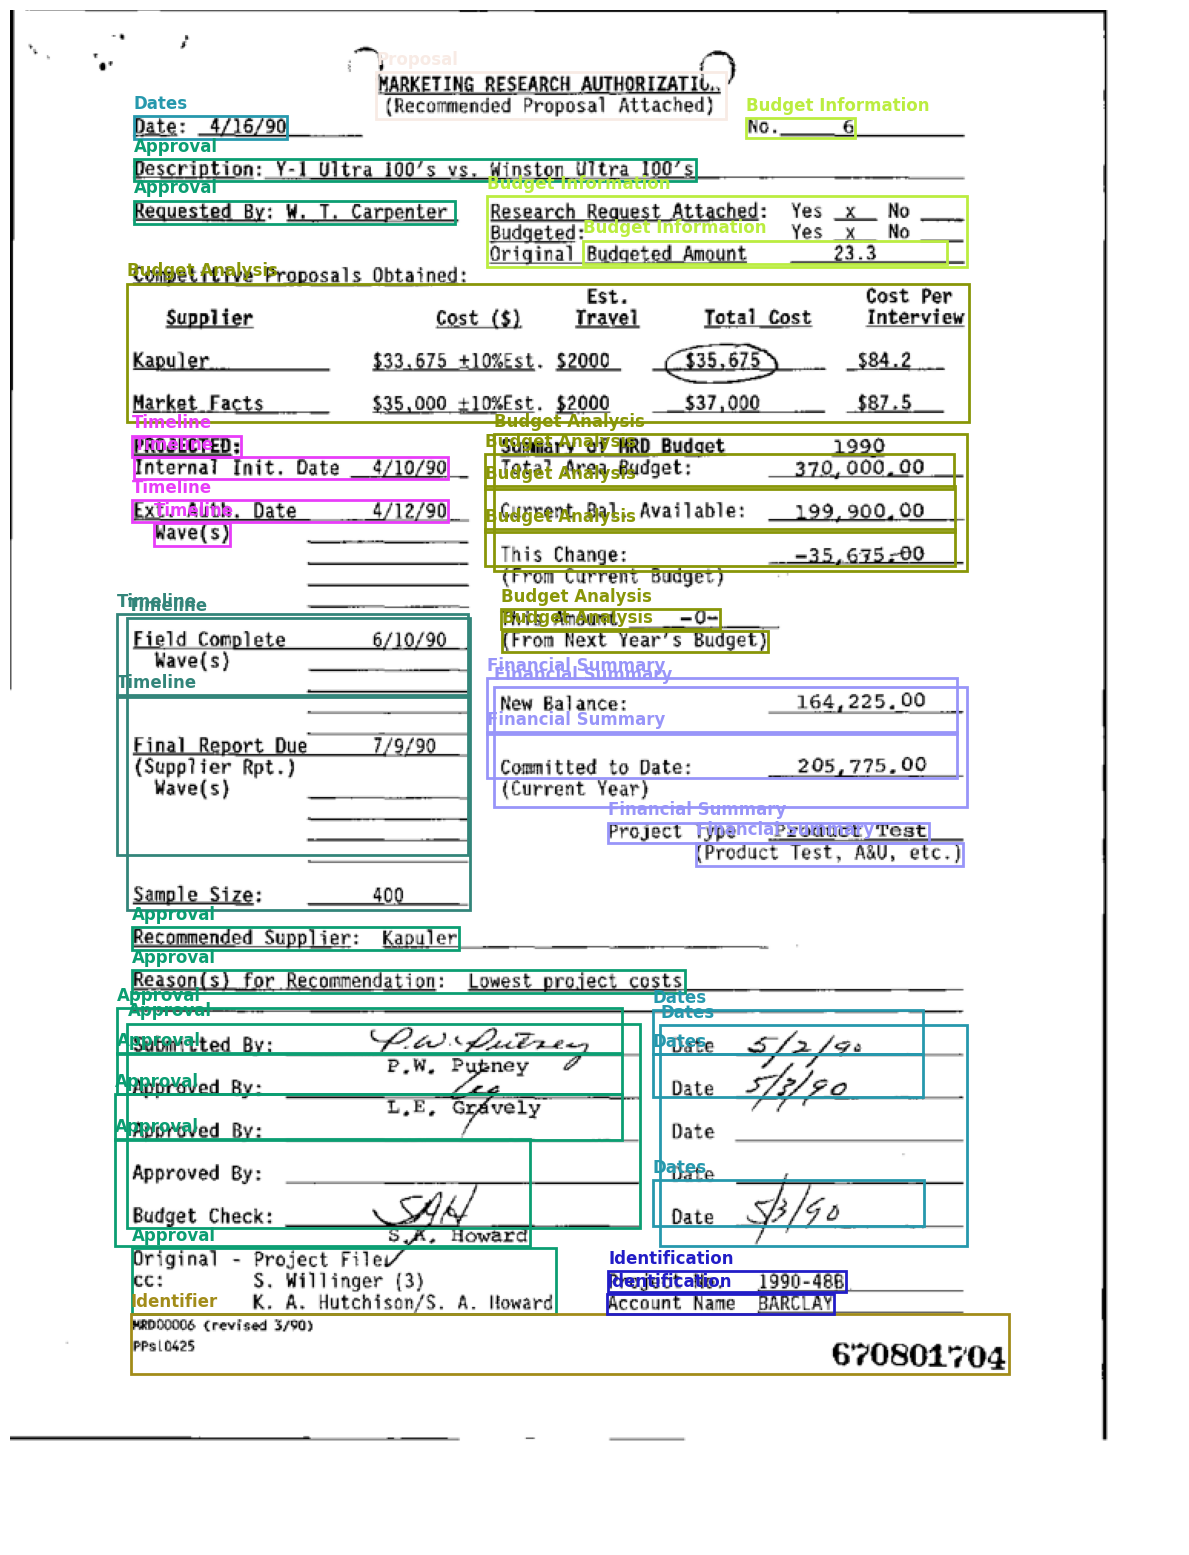

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from random import randint

def polygon_to_bbox(polygon):
    """
    Given a polygon as a list of points (each point a dict with x, y),
    compute the bounding box [x_min, y_min, x_max, y_max].
    """
    #xs = [pt["x"] for pt in polygon]
    #ys = [pt["y"] for pt in polygon]
    # Assume polygon is a flat list of numbers: [x1, y1, x2, y2, ...]
    pts = np.array(polygon).reshape(-1, 2)
    xs = pts[:, 0]
    ys = pts[:, 1]

    return [min(xs), min(ys), max(xs), max(ys)]

def plot_paragraph_boxes(image_path, paragraphs, labels, clusters=None):
    """
    image_path: path to the document image.
    paragraphs: a list of paragraph objects from OCR data.
      Each paragraph is assumed to have a 'boundingRegions' key containing a list of regions,
      and we use the first region's 'polygon' to compute the bounding box.
    labels: a dictionary of cluster labels corresponding to each paragraph,
            format {pid: {'label': 6, 'name': 'Cluster 6'}
    """
    # Read the image (OpenCV reads as BGR)
    img = cv2.imread(image_path)
    if img is None:
        print("Could not load image.")
        return

    # Convert image to RGB for matplotlib.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a matplotlib figure
    fig, ax = plt.subplots(1, figsize=(12, 16))
    ax.imshow(img_rgb)

    # Generate a color map for clusters. We'll create one color per unique label.
    # labels is now a dict
    unique_labels = sorted(set([value["label"] for value in labels.values()]))
    cmap = {}
    for lbl in unique_labels:
        # Random color: you can also use a predefined colormap.
        cmap[lbl] = (randint(0,255)/255.0, randint(0,255)/255.0, randint(0,255)/255.0)
    
    # Loop over paragraphs and plot bounding boxes.
    for para in paragraphs:
        # is it valid?
        if para.get("invalid", False):
            continue

        # get label from labels dict by paragraph id
        pid = int(para.get("id", -1))
        if pid < 0:
            continue
        lbl = labels[pid]["label"]
        name = labels[pid]["name"]

        #print(para)
        brs = para.get("boundingRegions", [])
        #print(brs)
        if not brs:
            continue
        # Use the first bounding region for plotting.
        poly = brs[0].get("polygon", [])
        #print(poly)
        if len(poly) < 4:
            continue
        
        bbox = polygon_to_bbox(poly)
        x_min, y_min, x_max, y_max = bbox
        width, height = x_max - x_min, y_max - y_min
        
        # Create a rectangle patch with the cluster color.
        rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2,
                                 edgecolor=cmap[lbl], facecolor='none')
        ax.add_patch(rect)
        # Optionally, add the cluster label as text
        if clusters:
            sem_name = clusters[lbl]["designation"]
            ax.text(x_min, y_min - 5, sem_name, color=cmap[lbl],
                fontsize=12, weight='bold')
        else:
            ax.text(x_min, y_min - 5, name, color=cmap[lbl],
                    fontsize=12, weight='bold')
    
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Example usage:
# Load OCR data (assumed to be a dictionary from your OCR JSON)
#with open("ocr_output.json", "r", encoding="utf-8") as f:
#    ocr_data = json.load(f)

# Extract paragraphs from OCR data. (This assumes a similar structure as provided.)
paragraphs = ocr_data.get("paragraphs", [])

# For demonstration, let's assume you have computed cluster labels for each paragraph.
# For instance, here we assign a random cluster label (in practice, use your clustering results).
#np.random.seed(42)
#labels = [np.random.randint(0, 5) for _ in range(len(paragraphs))]

# Path to your document image
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'

# Plot the bounding boxes with cluster labels.
plot_paragraph_boxes(image_path, paragraphs, cluster_labels, clusters=clusters)

Below is an example that assumes you already have your OCR paragraphs (each with a bounding region) and a corresponding list of cluster labels (in the same order as the paragraphs). The code groups paragraphs by cluster label and then sorts the paragraphs within each cluster by their vertical position (using the top coordinate of their bounding box). Finally, it aggregates the text for each cluster in the correct reading order.

---

### How This Code Works

1. **polygon_to_bbox:**  
   Converts a polygon (which may be a flat list of numbers or a list of dictionaries) into a bounding box \([x_{\text{min}}, y_{\text{min}}, x_{\text{max}}, y_{\text{max}}]\).

2. **get_paragraph_top:**  
   Extracts the top (y_min) coordinate from a paragraph’s first bounding region. This value is used for ordering paragraphs vertically.

3. **group_paragraphs_by_cluster:**  
   • First, groups the paragraph objects based on their cluster labels.  
   • Then sorts each group by the vertical position (using `get_paragraph_top`) and optionally by the left coordinate as a tiebreaker.  
   • Finally, it concatenates the text from each paragraph in order, using newline characters.

4. **main:**  
   • Loads the OCR JSON, extracts paragraphs, and uses a simulated clustering assignment (replace with your actual cluster labels).  
   • Then, groups and prints the aggregated text for each cluster.


In [25]:
import json
import numpy as np

def polygon_to_bbox(polygon):
    """
    Convert a flat polygon array into a bounding box [x_min, y_min, x_max, y_max].
    Assumes polygon is a flat list of numbers: [x1, y1, x2, y2, ...].
    """
    pts = np.array(polygon).reshape(-1, 2)
    x_min = float(pts[:, 0].min())
    y_min = float(pts[:, 1].min())
    x_max = float(pts[:, 0].max())
    y_max = float(pts[:, 1].max())
    return [x_min, y_min, x_max, y_max]

def union_bbox(bbox_list):
    """
    Given a list of bounding boxes [x_min, y_min, x_max, y_max],
    return the union bounding box that encloses them all.
    """
    if not bbox_list:
        return None
    xmins = [bbox[0] for bbox in bbox_list]
    ymins = [bbox[1] for bbox in bbox_list]
    xmaxs = [bbox[2] for bbox in bbox_list]
    ymaxs = [bbox[3] for bbox in bbox_list]
    return [min(xmins), min(ymins), max(xmaxs), max(ymaxs)]

def get_paragraph_top(para):
    """
    Return the top (y_min) coordinate from the first bounding region of a paragraph.
    If no bounding region exists, return infinity.
    """
    regions = para.get("boundingRegions", [])
    if not regions:
        return float('inf')
    poly = regions[0].get("polygon", [])
    if not poly:
        return float('inf')
    return polygon_to_bbox(poly)[1]

def group_paragraphs_by_cluster(paragraphs, labels_dict):
    """
    Group paragraphs by cluster and extract the cluster name at the same time.
    
    Parameters:
      paragraphs: List of paragraph objects from OCR JSON.
      labels_dict: Dictionary mapping paragraph id to label info.
    
    Returns:
      A dictionary where keys are cluster labels and values are dicts containing:
         - "name": the cluster name (from labels_dict)
         - "text": concatenated paragraph text in reading order
         - "boundingBox": union bounding box of all paragraphs in the cluster.
    """
    # Create a dictionary mapping cluster labels to {"name": <name>, "paragraphs": [...]}
    cluster_dict = {}
    for para in paragraphs:
        pid = para.get("id", -1)
        if pid in labels_dict:
            label = labels_dict[pid]["label"]
            name = labels_dict[pid]["name"]
            cluster_dict.setdefault(label, {"name": name, "paragraphs": []})
            cluster_dict[label]["paragraphs"].append(para)
    
    # Process each cluster to compute combined text and union bounding box.
    cluster_output = {}
    for lbl, data in cluster_dict.items():
        paras = data["paragraphs"]
        # Sort paragraphs by vertical position, using top coordinate, and x_min as tiebreaker.
        paras_sorted = sorted(
            paras,
            key=lambda p: (
                get_paragraph_top(p),
                polygon_to_bbox(p.get("boundingRegions", [])[0]["polygon"]) if p.get("boundingRegions", []) else [0,0,0,0]
            )
        )
        combined_text = "\n".join(p.get("content", "").strip() for p in paras_sorted)
        # Compute union bounding box using the first bounding region from each paragraph.
        bboxes = []
        for p in paras_sorted:
            if p.get("boundingRegions"):
                bboxes.append(polygon_to_bbox(p["boundingRegions"][0]["polygon"]))
        union_box = union_bbox(bboxes) if bboxes else None
        
        cluster_output[lbl] = {
            "name": data["name"],
            "text": combined_text,
            "boundingBox": union_box
        }
    return cluster_output

# Load OCR data (this assumes you have an OCR JSON file with a "paragraphs" key)
#with open("ocr_output.json", "r", encoding="utf-8") as f:
#    ocr_data = json.load(f)

paragraphs = ocr_data.get("paragraphs", [])

# Assume you already have computed cluster labels for each paragraph.
# For demonstration, here we simulate labels (replace with your clustering results).
# For example, assign cluster 0 for even indices and 1 for odd indices:
#labels = [0 if i % 2 == 0 else 1 for i in range(len(paragraphs))]

# Group and sort paragraphs by cluster
clusters = group_paragraphs_by_cluster(paragraphs, cluster_labels)

#print(json.dumps(clusters, indent=2))

# Print the aggregated text for each cluster in order.
for cluster_label in sorted(clusters.keys()):
    cluster = clusters[cluster_label]
    print(f"Cluster {cluster_label} ({cluster['name']}):")
    print(cluster['text'])
    print("=" * 80)


Cluster 0 (Cluster 0):
Competitive Proposals Obtained: Est. Cost Per Supplier Cost ($) Travel Total Cost Interview,,,,
Kapuler,$33.675 +10%Est.,$2000,:selected: $35,675,$84.2
Market Facts,$35.000 +10%Est.,$2000,$37,000,$87.5
Summary of MRD Budget,1990
Total Area Budget:,370,000.00
Current Bal. Available:,199,900.00
This Change:,-35,675.00
(From Current Budget),
Total Area Budget: 370,000.00
Current Bal. Available: 199,900.00
This Change: -35,675.00
This Amount -0-
(From Next Year's Budget)
Cluster 1 (Cluster 1):
Project No. 1990-488
Account Name BARCLAY
Cluster 2 (Cluster 2):
No. 6
,,Research,Request Attached:,Yes :selected: No
:unselected:
,,Budgeted:,,Yes :selected: No
:unselected:
,,Original,Budgeted Amount,23.3
Budgeted Amount 23.3
Cluster 3 (Cluster 3):
PROJECTED:
Internal Init. Date 4/10/90
Ext. Auth. Date 4/12/90
Wave(s)
Cluster 4 (Cluster 4):
Wave(s) 6/10/90
Field Complete,6/10/90
Wave(s),
Final Report Due,7/9/90
(Supplier Rpt.) Wave(s),
Sample Size:,400
(Supplier Rpt.) Wave(s)

Below is an example Python script that sends each cluster’s aggregated text to GPT‑4 via the OpenAI API and asks for a semantic designation (e.g., “Title”, “Introduction”, “Methodology”, “Results”, “Conclusion”) for that cluster. The code assumes you already have a dictionary mapping cluster labels to their combined text. You can adjust the prompt and parameters as needed.

### How It Works

1. **get_semantic_designation Function:**  
   - This function builds a prompt that instructs GPT‑4 to assign a semantic designation to the provided cluster text.
   - It uses `openai.ChatCompletion.create` with a system message (setting context) and a user message (with the prompt).
   - The function extracts and returns the semantic designation from GPT‑4's response.

2. **Main Function:**  
   - We assume a dictionary `clusters` where keys are cluster IDs and values are the aggregated text of each cluster.
   - For each cluster, the script calls `get_semantic_designation` and prints the result.
   - Finally, it saves the designations to a JSON file.

3. **Customization:**  
   - Adjust the prompt if you need different instructions.
   - Change the temperature or max_tokens to tweak response style and length.
   - Replace the demo `clusters` dictionary with your actual clustered data.

This script provides a complete pipeline to have GPT‑4 determine the semantic designation for each text cluster extracted from your document.

In [29]:
from openai import OpenAI
import json
import os

# Make sure your OpenAI API key is set in your environment:
# export OPENAI_API_KEY="your_api_key_here"

def get_semantic_designation(cluster_text):
    """
    Uses GPT‑4 via ChatCompletion to determine a semantic designation for the given cluster text.
    Returns the designation as a string.
    """
    prompt = (
        "You are a helpful assistant that assigns a semantic designation to a document text cluster. "
        "Based on the text provided, please output a one- or two-word designation that best describes "
        "the key concept of the text (for example: 'Title', 'Introduction', 'Methodology', 'Results', "
        "'Conclusion', etc.).\n\n"
        "Cluster Text:\n" + cluster_text + "\n\n"
        "Semantic Designation:"
    )

    client = OpenAI(
        api_key=os.environ.get("OPENAI_API_KEY"),  # This is the default and can be omitted
    )
    
    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": "You are an expert in document analysis."},
            {"role": "user", "content": prompt}
        ],
        model="gpt-4o",
        temperature=0.3,
        max_tokens=30
    )
    
    # Extract the generated designation from the response.
    designation = response.choices[0].message.content.strip()
    return designation

# ask GPT for its opinion on semantic designation and add to clusters
for label, cluster in clusters.items():
    # run semantic designation 
    designation = get_semantic_designation(cluster["text"])
    cluster["designation"] = designation
    print(f"Cluster {label} ({cluster['name']}) is designated as: {designation}\n")

# print results
print(json.dumps(clusters, indent=2))


Cluster 8 (title) is designated as: Proposal

Cluster 6 (Cluster 6) is designated as: Dates

Cluster 7 (Cluster 7) is designated as: Approval

Cluster 3 (Cluster 3) is designated as: Timeline

Cluster 0 (Cluster 0) is designated as: Budget Analysis

Cluster 5 (Cluster 5) is designated as: Financial Summary

Cluster 9 (pageFooter) is designated as: Identifier

Cluster 2 (Cluster 2) is designated as: Budget Information

Cluster 4 (Cluster 4) is designated as: Timeline

Cluster 1 (Cluster 1) is designated as: Identification

{
  "8": {
    "name": "title",
    "text": "MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)",
    "boundingBox": [
      238.0,
      40.0,
      466.0,
      71.0
    ],
    "designation": "Proposal"
  },
  "6": {
    "name": "Cluster 6",
    "text": "Date: 4/16/90\nDate 5/2/90\n,Date,5/2/90\n,Date,5/3/90\n,Date,\n,Date,\n,Date,5/3/90\nDate 5/3/90\nDate 5/3/90",
    "boundingBox": [
      80.0,
      69.0,
      623.0,
      805.0
    ],
    "desi

---

## The section below manipulates the JSON document to combine paragraphs of key-value pairs and paragraphs in tables/figures

---

Below is an example Python script that updates your OCR JSON so that for each key‑value pair it finds the paragraph containing the key and the paragraph containing the value (using bounding box overlap), appends the value text into the key paragraph (updating its bounding box accordingly), and then removes the value paragraph from the document. You may need to adjust the matching threshold for your data.

---

### Explanation

1. **polygon_to_bbox & union_bbox:**  
   These functions compute the bounding box for a given polygon and then take the union of multiple bounding boxes.

2. **compute_iou:**  
   Computes the Intersection over Union (IoU) between two bounding boxes. We use IoU to decide which paragraph best matches the key’s and value’s bounding regions.

3. **get_paragraph_bbox:**  
   Computes the union bounding box for a paragraph by combining all its bounding regions (each of which is assumed to hold a flat polygon array).

4. **merge_key_value_pairs_in_paragraphs:**  
   - Iterates over each keyValuePair.
   - For each, it computes a union bounding box for the key and for the value.
   - Then it iterates through the paragraphs and finds the paragraph that best overlaps with the key’s bbox and the paragraph that best overlaps with the value’s bbox (using IoU).
   - If these are different paragraphs and the IoU values exceed a threshold, the function updates the key paragraph’s text (by appending the value text) and its bounding box (as the union of both paragraphs’ boxes). Finally, it marks the value paragraph for removal.
   - After processing all pairs, the paragraphs marked for removal are deleted from the OCR JSON.

5. **main:**  
   Loads the OCR JSON from file, processes it with the merge function, and writes the modified JSON out.

This approach updates your OCR JSON so that each key‑value pair is merged into the paragraph that contains the key, with the value text and a union bounding box, and the separate paragraph containing the value is removed. Adjust thresholds and processing details as needed for your data.

In [ ]:
import os
import json
import numpy as np

def bbox_to_polygon(bbox):
    """
    Convert a bounding box [x_min, y_min, x_max, y_max] into a flattened polygon array 
    with four points: top-left, top-right, bottom-right, bottom-left.
    """
    x_min, y_min, x_max, y_max = bbox
    return [x_min, y_min, x_max, y_min, x_max, y_max, x_min, y_max]

def polygon_to_bbox(polygon):
    """
    Convert a flat polygon array into a bounding box [x_min, y_min, x_max, y_max].
    The polygon is expected to be a flat list of numbers: [x1, y1, x2, y2, ...].
    """
    pts = np.array(polygon).reshape(-1, 2)
    x_min = float(pts[:, 0].min())
    y_min = float(pts[:, 1].min())
    x_max = float(pts[:, 0].max())
    y_max = float(pts[:, 1].max())
    return [x_min, y_min, x_max, y_max]

def union_bbox(bbox_list):
    """
    Given a list of bounding boxes [x_min, y_min, x_max, y_max],
    compute the union bounding box that encloses all of them.
    """
    if not bbox_list:
        return None
    xmins = [bbox[0] for bbox in bbox_list]
    ymins = [bbox[1] for bbox in bbox_list]
    xmaxs = [bbox[2] for bbox in bbox_list]
    ymaxs = [bbox[3] for bbox in bbox_list]
    return [min(xmins), min(ymins), max(xmaxs), max(ymaxs)]

def compute_iou(bbox1, bbox2):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.
    Each bbox is in the form [x_min, y_min, x_max, y_max].
    """
    xA = max(bbox1[0], bbox2[0])
    yA = max(bbox1[1], bbox2[1])
    xB = min(bbox1[2], bbox2[2])
    yB = min(bbox1[3], bbox2[3])
    
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    
    box1Area = (bbox1[2]-bbox1[0]) * (bbox1[3]-bbox1[1])
    box2Area = (bbox2[2]-bbox2[0]) * (bbox2[3]-bbox2[1])
    
    unionArea = box1Area + box2Area - interArea
    if unionArea == 0:
        return 0
    return interArea / unionArea

def get_paragraph_bbox(para):
    """
    Compute the union bounding box for a paragraph by combining all its boundingRegions.
    Assumes each region has a flat polygon array under "polygon".
    """
    bboxes = []
    for region in para.get("boundingRegions", []):
        poly = region.get("polygon", [])
        if poly:
            bboxes.append(polygon_to_bbox(poly))
    if bboxes:
        return union_bbox(bboxes)
    return None

def merge_key_value_pairs_in_paragraphs(ocr_json, iou_threshold=0.1):
    """
    For each keyValuePair in the OCR JSON, find the paragraph that best matches the key and
    the paragraph that best matches the value (using IoU on bounding boxes). Then update the key paragraph:
      - Append the value text to the key text.
      - Update the paragraph's boundingRegions with the union of the key and value bounding boxes.
    Finally, remove the paragraph corresponding to the value.
    
    Returns the modified OCR JSON.
    """
    paragraphs = ocr_json.get("paragraphs", [])
    # Keep track of indices to remove (value paragraphs)
    remove_indices = set()

    for kv in ocr_json.get("keyValuePairs", []):
        # Compute union bbox for key and for value
        key_regions = kv.get("key", {}).get("boundingRegions", [])
        value_regions = kv.get("value", {}).get("boundingRegions", [])
        if not key_regions or not value_regions:
            continue
        
        key_bboxes = [polygon_to_bbox(r.get("polygon", [])) for r in key_regions if r.get("polygon")]
        value_bboxes = [polygon_to_bbox(r.get("polygon", [])) for r in value_regions if r.get("polygon")]
        if not key_bboxes or not value_bboxes:
            continue
        
        key_bbox = union_bbox(key_bboxes)
        value_bbox = union_bbox(value_bboxes)
        
        # For each paragraph, compute its bbox and then IoU with key_bbox and value_bbox.
        best_key_iou = 0
        best_key_idx = None
        best_value_iou = 0
        best_value_idx = None

        for idx, para in enumerate(paragraphs):
            para_bbox = get_paragraph_bbox(para)
            if para_bbox is None:
                continue
            iou_key = compute_iou(key_bbox, para_bbox)
            iou_value = compute_iou(value_bbox, para_bbox)
            if iou_key > best_key_iou:
                best_key_iou = iou_key
                best_key_idx = idx
            if iou_value > best_value_iou:
                best_value_iou = iou_value
                best_value_idx = idx

        # Only update if both key and value paragraphs were found
        if best_key_idx is not None and best_value_idx is not None and best_key_idx != best_value_idx:
            # Optionally, require a minimum IoU to be sure they match
            if best_key_iou >= iou_threshold and best_value_iou >= iou_threshold:
                key_para = paragraphs[best_key_idx]
                value_para = paragraphs[best_value_idx]
                
                # Update key paragraph: append value content (if not already present)
                key_text = key_para.get("content", "").strip()
                value_text = value_para.get("content", "").strip()
                # For safety, check if value_text is already a substring
                if value_text and value_text not in key_text:
                    merged_text = key_text + " " + value_text
                else:
                    merged_text = key_text

                key_para["content"] = merged_text
                
                # Update boundingRegions: union the bounding boxes.
                key_bbox_existing = get_paragraph_bbox(key_para)
                value_bbox_existing = get_paragraph_bbox(value_para)
                merged_bbox = bbox_to_polygon(union_bbox([key_bbox_existing, value_bbox_existing]))
                #print("mbox", merged_bbox)
                # Replace boundingRegions with a single region using the merged bbox.
                # You may choose a different format if needed.
                key_para["boundingRegions"] = [{
                    "pageNumber": key_regions[0].get("pageNumber", None),
                    "polygon": merged_bbox  # Note: merged_bbox is a list [x_min, y_min, x_max, y_max]
                }]
                
                # Mark the value paragraph for removal.
                remove_indices.add(best_value_idx)
    
    # Remove paragraphs with indices in remove_indices, in reverse order.
    for idx in sorted(remove_indices, reverse=True):
        del paragraphs[idx]
    
    ocr_json["paragraphs"] = paragraphs
    return ocr_json

# Path to your OCR JSON file
#input_path = "ocr_output.json"   # Replace with your actual input path
output_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged2.json'

# Load the OCR JSON
# with open(input_path, "r", encoding="utf-8") as f:
#     ocr_data = json.load(f)

# Merge the key-value pairs
modified_ocr = merge_key_value_pairs_in_paragraphs(ocr_data, iou_threshold=0.1)

# Write the modified OCR JSON to a file
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(modified_ocr, f, indent=2)

print(f"Modified OCR JSON with merged key-value pairs written to {output_path}")


mbox [479.0, 70.0, 550.0, 70.0, 550.0, 83.0, 479.0, 83.0]
mbox [373.0, 150.0, 610.0, 150.0, 610.0, 165.0, 373.0, 165.0]
mbox [80.0, 291.0, 285.0, 291.0, 285.0, 305.0, 80.0, 305.0]
mbox [309.0, 289.0, 614.0, 289.0, 614.0, 312.0, 309.0, 312.0]
mbox [79.0, 319.0, 285.0, 319.0, 285.0, 333.0, 79.0, 333.0]
mbox [309.0, 310.0, 615.0, 310.0, 615.0, 340.0, 309.0, 340.0]
mbox [309.0, 338.0, 615.0, 338.0, 615.0, 362.0, 309.0, 362.0]
mbox [319.0, 390.0, 462.0, 390.0, 462.0, 403.0, 319.0, 403.0]
mbox [69.0, 393.0, 298.0, 393.0, 298.0, 447.0, 69.0, 447.0]
mbox [310.0, 435.0, 616.0, 435.0, 616.0, 471.0, 310.0, 471.0]
mbox [69.0, 446.0, 298.0, 446.0, 298.0, 550.0, 69.0, 550.0]
mbox [310.0, 470.0, 616.0, 470.0, 616.0, 500.0, 310.0, 500.0]
mbox [389.0, 529.0, 598.0, 529.0, 598.0, 542.0, 389.0, 542.0]
mbox [79.0, 597.0, 292.0, 597.0, 292.0, 612.0, 79.0, 612.0]
mbox [79.0, 625.0, 439.0, 625.0, 439.0, 640.0, 79.0, 640.0]
mbox [69.0, 650.0, 398.0, 650.0, 398.0, 680.0, 69.0, 680.0]
mbox [418.0, 651.0, 594.0,

## Atomic Key-Pairs by generating paragraph representation 

### Overview
Below is an updated version of the merging code. In this version, instead of creating a separate key (e.g. `"mergedParagraphs"`), the new merged paragraphs are appended directly into the `"paragraphs"` list. The original paragraphs that contributed to a merge are marked with `"invalid": true` and a `"mergedInto"` pointer, so you can later filter or review them if needed.

### TODO
Fix paragraph numbering so merged paragraphs ids are numbered starting with the current maximum + 1. See Atomic Table code for example.

Done.

---

### How This Code Works

- **Helper Functions:**  
  - `polygon_to_bbox` converts a flat polygon array into a bounding box.  
  - `union_bbox` computes the union of multiple bounding boxes.  
  - `compute_iou` computes the intersection-over-union between two boxes.  
  - `get_paragraph_bbox` computes the overall bounding box of a paragraph by unioning its regions.

- **create_merged_paragraph:**  
  Constructs a new paragraph element with merged content and a union bounding box. It also stores `"contributingParagraphs"` that lists the IDs (or indices) of the original key and value paragraphs.

- **merge_key_value_pairs_create_new_paragraphs:**  
  For each key–value pair in the OCR JSON, it identifies the best matching paragraphs for the key and value (using IoU) and then creates a new merged paragraph element. Instead of replacing the key paragraph or deleting the value paragraph, the merged paragraph is appended to the `"paragraphs"` list. The original paragraphs are marked with `"invalid": True` and have a `"mergedInto"` field pointing to the new merged paragraph’s ID.

- **main:**  
  Loads the OCR JSON, processes it with the merging function, and writes the updated JSON back to disk.

This approach keeps the original paragraph structure intact while appending new merged paragraphs. This makes it easier to trace the original data and extend merging logic (for example, merging key–value pairs inside tables) in the future.

### Notes
This code required updates to the clustering code namely,
1. Recognize the `invalid` flag and ignore paragraph if required
2. Save the actual paragraph `ids` in a dictionary version of `cluster_labels` rather than relying on the order the paragraphs are in the JSON.

In [9]:
import os
import json
import numpy as np

def get_max_paragraph_id(ocr_json):
    """
    Return the maximum paragraph id among the paragraphs.
    """
    ids = []
    for para in ocr_json.get("paragraphs", []):
        try:
            ids.append(int(para.get("id")))
        except Exception:
            continue
    print("ids", ids)
    return max(ids) if ids else 1000

def polygon_to_bbox(polygon):
    """
    Convert a flat polygon array into a bounding box [x_min, y_min, x_max, y_max].
    Assumes polygon is a flat list of numbers: [x1, y1, x2, y2, ...].
    """
    pts = np.array(polygon).reshape(-1, 2)
    x_min = float(pts[:, 0].min())
    y_min = float(pts[:, 1].min())
    x_max = float(pts[:, 0].max())
    y_max = float(pts[:, 1].max())
    return [x_min, y_min, x_max, y_max]

def bbox_to_polygon(bbox):
    """
    Convert a bounding box [x_min, y_min, x_max, y_max] into a flattened polygon array 
    with four points: top-left, top-right, bottom-right, bottom-left.
    """
    x_min, y_min, x_max, y_max = bbox
    return [x_min, y_min, x_max, y_min, x_max, y_max, x_min, y_max]

def union_bbox(bbox_list):
    """
    Given a list of bounding boxes [x_min, y_min, x_max, y_max],
    return the union bounding box that encloses them all.
    """
    if not bbox_list:
        return None
    xmins = [b[0] for b in bbox_list]
    ymins = [b[1] for b in bbox_list]
    xmaxs = [b[2] for b in bbox_list]
    ymaxs = [b[3] for b in bbox_list]
    return [min(xmins), min(ymins), max(xmaxs), max(ymaxs)]

def compute_iou(bbox1, bbox2):
    """Compute Intersection over Union (IoU) for two bounding boxes."""
    xA = max(bbox1[0], bbox2[0])
    yA = max(bbox1[1], bbox2[1])
    xB = min(bbox1[2], bbox2[2])
    yB = min(bbox1[3], bbox2[3])
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    area1 = (bbox1[2]-bbox1[0]) * (bbox1[3]-bbox1[1])
    area2 = (bbox2[2]-bbox2[0]) * (bbox2[3]-bbox2[1])
    unionArea = area1 + area2 - interArea
    return interArea / unionArea if unionArea else 0

def get_paragraph_bbox(para):
    """
    Compute the overall bounding box for a paragraph by unioning its boundingRegions.
    """
    bboxes = []
    for region in para.get("boundingRegions", []):
        poly = region.get("polygon", [])
        if poly:
            bboxes.append(polygon_to_bbox(poly))
    if bboxes:
        return union_bbox(bboxes)
    return None

def create_merged_paragraph(key_para, value_para):
    """
    Create a new merged paragraph element.
    The new paragraph element will:
      - Concatenate key and value content.
      - Compute a merged bounding box (union of key and value bboxes),
        then convert that bbox into a full polygon with 8 entries.
      - Create a new span.
      - Record contributing paragraph IDs.
    """
    key_text = key_para.get("content", "").strip()
    value_text = value_para.get("content", "").strip()
    merged_text = key_text + " " + value_text if value_text not in key_text else key_text

    key_bbox = get_paragraph_bbox(key_para)
    value_bbox = get_paragraph_bbox(value_para)
    merged_bbox = union_bbox([key_bbox, value_bbox])
    merged_poly = bbox_to_polygon(merged_bbox) if merged_bbox else []

    # Copy pageNumber from key paragraph's first bounding region if available.
    page_number = None
    if key_para.get("boundingRegions"):
        page_number = key_para["boundingRegions"][0].get("pageNumber")

    merged_region = {
        "pageNumber": page_number,
        "polygon": merged_poly
    }
    
    new_span = {"offset": 0, "length": len(merged_text)}
    
    merged_para = {
        "content": merged_text,
        "boundingRegions": [merged_region],
        "spans": [new_span],
        "contributingParagraphs": [key_para.get("id", None), value_para.get("id", None)]
    }
    return merged_para

def merge_key_value_pairs_create_new_paragraphs(ocr_json, iou_threshold=0.1):
    """
    Process each keyValuePair in the OCR JSON:
      - Identify the best matching key paragraph and value paragraph.
      - Create a new merged paragraph element.
      - Append the new merged paragraph into the OCR JSON's "paragraphs" list.
      - Mark the original key and value paragraphs with "invalid": True and "mergedInto": <merged_id>.
    """
    paragraphs = ocr_json.get("paragraphs", [])
    
    # Ensure each paragraph has an "id"
    for idx, para in enumerate(paragraphs):
        if "id" not in para:
            para["id"] = idx

    new_merged_paragraphs = []
    merged_paragraphs_current_id = get_max_paragraph_id(ocr_json) + 1

    for kv in ocr_json.get("keyValuePairs", []):
        key_obj = kv.get("key", {})
        value_obj = kv.get("value", {})
        if not key_obj or not value_obj:
            continue

        key_bboxes = [polygon_to_bbox(r.get("polygon", []))
                      for r in key_obj.get("boundingRegions", [])
                      if r.get("polygon")]
        value_bboxes = [polygon_to_bbox(r.get("polygon", []))
                        for r in value_obj.get("boundingRegions", [])
                        if r.get("polygon")]
        if not key_bboxes or not value_bboxes:
            continue

        key_bbox_union = union_bbox(key_bboxes)
        value_bbox_union = union_bbox(value_bboxes)

        best_key_iou = 0
        best_key_idx = None
        best_value_iou = 0
        best_value_idx = None

        for idx, para in enumerate(paragraphs):
            para_bbox = get_paragraph_bbox(para)
            if para_bbox is None:
                continue
            iou_key = compute_iou(key_bbox_union, para_bbox)
            iou_value = compute_iou(value_bbox_union, para_bbox)
            if iou_key > best_key_iou:
                best_key_iou = iou_key
                best_key_idx = idx
            if iou_value > best_value_iou:
                best_value_iou = iou_value
                best_value_idx = idx

        if (best_key_idx is not None and best_value_idx is not None and 
            best_key_idx != best_value_idx and 
            best_key_iou >= iou_threshold and best_value_iou >= iou_threshold):
            
            key_para = paragraphs[best_key_idx]
            value_para = paragraphs[best_value_idx]

            merged_para = create_merged_paragraph(key_para, value_para)
            # Assign a new ID to the merged paragraph.
            merged_para["id"] = merged_paragraphs_current_id #f"merged_{key_para.get('id')}_{value_para.get('id')}"
            merged_paragraphs_current_id += 1
            new_merged_paragraphs.append(merged_para)
            
            # Mark original paragraphs as merged.
            key_para["invalid"] = True
            key_para["mergedInto"] = merged_para["id"]
            value_para["invalid"] = True
            value_para["mergedInto"] = merged_para["id"]

    # Append new merged paragraphs to the existing paragraphs list.
    ocr_json["paragraphs"].extend(new_merged_paragraphs)
    return ocr_json

input_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout.json'   # Update with your OCR JSON file path
output_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged4.json'

with open(input_path, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

updated_ocr = merge_key_value_pairs_create_new_paragraphs(ocr_data, iou_threshold=0.1)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(updated_ocr, f, indent=2)

print(f"Updated OCR JSON written to {output_path}")


ids [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]
Updated OCR JSON written to ../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged4.json


## Atomic Tables by generating paragraph representation 

### Overview
Below is an updated version of the merge function that, for each table, uses the table’s own `"boundingRegions"` (as provided in the table JSON) for the new merged paragraph. This code converts the table’s content into CSV text, creates a new paragraph element whose `"boundingRegions"` is taken directly from the table, and then marks any paragraphs referenced by the table as invalid while appending the new merged paragraph into the existing `"paragraphs"` list.

### TODO
Need to look after previously merged key-value pairs

Update: Now invalidating merged to paragraphs. For this set the merged to occures twice in all cases, i.e. both parts of key pairs exist in the same tables.

---

### Explanation

1. **get_table_csv:**  
   Converts table cell contents into a CSV-formatted string based on row and column indices.

2. **find_paragraph_by_pointer:**  
   Finds a paragraph in the OCR JSON by parsing a pointer string like `"/paragraphs/6"`.

3. **get_max_paragraph_id:**  
   Determines the maximum existing paragraph ID so that new merged paragraphs can get a unique ID.

4. **merge_table_to_paragraph:**  
   - For each table, the CSV text is generated.
   - The table’s `"boundingRegions"` are used directly (without recomputing a union).
   - All paragraph IDs referenced by table cells are collected as contributing paragraphs.
   - A new merged paragraph is created with the CSV text, the table's bounding regions, a span covering the CSV text, and a `"contributingParagraphs"` key.
   - Each contributing paragraph is then marked with `"invalid": true` and a `"mergedInto"` pointer.
   - Finally, the new paragraph is appended to the existing `"paragraphs"` list.

This approach allows you to incorporate table data into the paragraph structure while preserving the original OCR data for review or further processing.

In [10]:
import os
import json

def get_table_csv(table):
    """
    Convert a table's cell contents into a CSV string.
    Uses the "rowIndex" and "columnIndex" to build a grid.
    """
    rows = table.get("rowCount", 0)
    cols = table.get("columnCount", 0)
    # Initialize grid with empty strings.
    grid = [["" for _ in range(cols)] for _ in range(rows)]
    
    for cell in table.get("cells", []):
        row = cell.get("rowIndex", 0)
        col = cell.get("columnIndex", 0)
        text = cell.get("content", "").strip()
        grid[row][col] = text

    # Create CSV lines by joining each row with commas.
    csv_lines = [",".join(row) for row in grid]
    return "\n".join(csv_lines)

def find_paragraph_by_pointer(ocr_json, pointer):
    """
    Given a pointer string (e.g., "/paragraphs/6"), return the corresponding paragraph object
    from ocr_json["paragraphs"]. Assumes pointer format is fixed.
    """
    try:
        _, _, id_str = pointer.partition("/paragraphs/")
        target_id = int(id_str)
    except Exception:
        return None

    for para in ocr_json.get("paragraphs", []):
        try:
            if int(para.get("id", -1)) == target_id:
                return para
        except Exception:
            continue
    return None

def get_max_paragraph_id(ocr_json):
    """
    Return the maximum paragraph id among the paragraphs.
    """
    ids = []
    for para in ocr_json.get("paragraphs", []):
        try:
            ids.append(int(para.get("id")))
        except Exception:
            continue
    return max(ids) if ids else 0

def merge_table_to_paragraph(ocr_json):
    """
    For each table in ocr_json["tables"]:
      - Convert the table cells to CSV text.
      - Use the table's own "boundingRegions" as the new paragraph's boundingRegions.
      - For each cell that references a paragraph via "elements", mark that paragraph as invalid and set "mergedInto".
      - Create a new paragraph element with:
          * "content": the CSV text,
          * "boundingRegions": the table's boundingRegions,
          * "spans": a new span covering the CSV text,
          * "contributingParagraphs": a list of paragraph ids referenced by the table.
      - Append the new paragraph to ocr_json["paragraphs"].
    """
    paragraphs = ocr_json.get("paragraphs", [])
    
    # Ensure each paragraph has an "id"
    for idx, para in enumerate(paragraphs):
        if "id" not in para:
            para["id"] = idx

    max_id = get_max_paragraph_id(ocr_json)
    new_paragraphs = []

    for table in ocr_json.get("tables", []):
        csv_text = get_table_csv(table)
        
        # Use the table's boundingRegions directly.
        table_regions = table.get("boundingRegions", [])
        if not table_regions:
            continue
        
        # Collect contributing paragraph ids from the table's cells.
        contributing_ids = set()
        for cell in table.get("cells", []):
            for pointer in cell.get("elements", []):
                para_obj = find_paragraph_by_pointer(ocr_json, pointer)
                if para_obj and "id" in para_obj:
                    contributing_ids.add(int(para_obj["id"]))
        
        # Create a new paragraph element for the merged table.
        new_id = max_id + 1
        max_id += 1
        new_para = {
            "id": new_id,
            "content": csv_text,
            "boundingRegions": table_regions,  # Directly use table's boundingRegions.
            "spans": [{"offset": 0, "length": len(csv_text)}],
            "contributingParagraphs": list(contributing_ids)
        }
        new_paragraphs.append(new_para)
        print(f"New paragraph {json.dumps(new_para)}")
        
        # Mark the contributing paragraphs as invalid and note their mergedInto.
        for pid in contributing_ids:
            for para in paragraphs:
                try:
                    if int(para.get("id")) == pid:
                        para["invalid"] = True

                        # if previously merged we need to invalidate the merged to paragraph
                        merged_to_p = int(para.get("mergedInto", -1))

                        if merged_to_p != -1:
                            # find the para with that id
                            result_p = next((para for para in ocr_data["paragraphs"] if int(para.get("id", -1)) == merged_to_p), None)
                            if result_p:
                                print("Found paragraph:", result_p)
                                # set it invalid
                                result_p["invalid"] = True
                            # else:
                            #     print("Paragraph not found.")
                        
                        # point each paragraph to our new addition
                        para["mergedInto"] = new_id
                except Exception:
                    continue

    # Append new merged paragraphs into the existing paragraphs list.
    ocr_json["paragraphs"].extend(new_paragraphs)
    return ocr_json

input_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged4.json'  # Update with your input file path.
output_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged4b.json'

with open(input_path, "r", encoding="utf-8") as f:
    updated_ocr = json.load(f)

# take JSON after fixing key-pairs
updated_table_ocr = merge_table_to_paragraph(updated_ocr)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(updated_table_ocr, f, indent=2)

print(f"Updated OCR JSON with merged table paragraphs written to {output_path}")


New paragraph {"id": 111, "content": ",,Research,Request Attached:,Yes :selected: No\n:unselected:\n,,Budgeted:,,Yes :selected: No\n:unselected:\n,,Original,Budgeted Amount,23.3", "boundingRegions": [{"pageNumber": 1, "polygon": [311, 121, 623, 121, 623, 167, 310, 167]}], "spans": [{"offset": 0, "length": 135}], "contributingParagraphs": [6, 7, 8, 9, 10, 11, 12, 13]}
Found paragraph: {'content': 'Budgeted Amount 23.3', 'boundingRegions': [{'pageNumber': 1, 'polygon': [373.0, 150.0, 610.0, 150.0, 610.0, 165.0, 373.0, 165.0]}], 'spans': [{'offset': 0, 'length': 20}], 'contributingParagraphs': [12, 13], 'id': 88}
Found paragraph: {'content': 'Budgeted Amount 23.3', 'boundingRegions': [{'pageNumber': 1, 'polygon': [373.0, 150.0, 610.0, 150.0, 610.0, 165.0, 373.0, 165.0]}], 'spans': [{'offset': 0, 'length': 20}], 'contributingParagraphs': [12, 13], 'id': 88, 'invalid': True}
New paragraph {"id": 112, "content": "Competitive Proposals Obtained: Est. Cost Per Supplier Cost ($) Travel Total Co